# Monobank Finance X-Ray: Exploratory Data Analysis (EDA)

The goal of this notebook is to analyze raw transaction data retrieved from the Monobank API, understand spending patterns, and identify potential features for future Machine Learning models (e.g., anomaly detection, category clustering).

## 1. Environment Setup & Data Loading
Importing required modules and initializing our custom ETL pipeline components.

In [10]:
import os
import sys
import time
import pandas as pd

sys.path.append(os.path.abspath('..'))

from src.api_client import MonoClient
from src.processor import DataProcessor
from dotenv import load_dotenv

load_dotenv('../.env')

client = MonoClient()
processor = DataProcessor()
target_account = os.getenv("MONOBANK_ACCOUNT_ID")

print("Client and processor successfully loaded")

Client and processor successfully loaded


## 2. Fetching Recent Transactions
Retrieving the last 30 days of transaction history using our `MonoClient` and cleaning the raw JSON into a structured Pandas DataFrame via `DataProcessor`.

In [11]:
time_to = int(time.time())
time_from = time_to - (30 * 24 * 60 * 60)

raw_data = client.get_statement(target_account, time_from, time_to)

df = processor.clean_transactions(raw_data)

print(f"There are {len(df)} transactions.")

df.head()

There are 108 transactions.


,id,time,description,mcc,amount,balance,cashbackAmount
0,aDOwX7bslIzZJsUcTQ,2026-06-02 16:00:14,Від: Андрій Щербінін,4829,408.00,424.48,0.00
1,XKwlba2-LKDl-BbgAQ,2026-06-02 15:41:23,Маркетопт,5499,-65.80,16.48,0.65
2,KPEkOJ3JGuKdE0_32A,2026-06-02 15:40:57,Маркетопт,5499,-435.00,82.28,4.35
3,kY1PZBLdEOEgcaMovw,2026-06-02 15:24:09,Рідне село,5499,-280.13,517.28,2.80
4,9Tm70sc1MW5RhqI75Q,2026-06-02 15:22:13,Рідне село,5499,-26.00,797.41,0.26


## 3. Basic Data Inspection
Checking data types, missing values, and basic statistical summaries of our financial data.

In [12]:
print("Dataset info:")
df.info()

print("\nStatistical summary:")
display(df.describe())

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype        
---  ------          --------------  -----        
 0   id              108 non-null    str          
 1   time            108 non-null    datetime64[s]
 2   description     108 non-null    str          
 3   mcc             108 non-null    int64        
 4   amount          108 non-null    float64      
 5   balance         108 non-null    float64      
 6   cashbackAmount  108 non-null    float64      
dtypes: datetime64[s](1), float64(3), int64(1), str(2)
memory usage: 6.0 KB

Statistical summary:


,time,mcc,amount,balance,cashbackAmount
count,108,108.000000,108.000000,108.000000,108.000000
mean,2026-05-18 11:14:44,5248.916667,-5.384537,935.764815,0.830833
min,2026-05-03 20:32:58,4111.000000,-2324.800000,0.270000,0.000000
25%,2026-05-11 17:38:49,4829.000000,-143.150000,259.105000,0.000000
50%,2026-05-18 02:14:18,5411.000000,-30.800000,680.390000,0.000000
75%,2026-05-25 19:54:25,5499.000000,-8.000000,1399.547500,0.650000
max,2026-06-02 16:00:14,8099.000000,4000.000000,4439.450000,20.000000
std,NaN,841.394594,607.751965,892.895748,2.654147


## 4. Data Visualization
Visualizing balance trends and daily expense distributions to identify behavioral patterns and potential outliers.

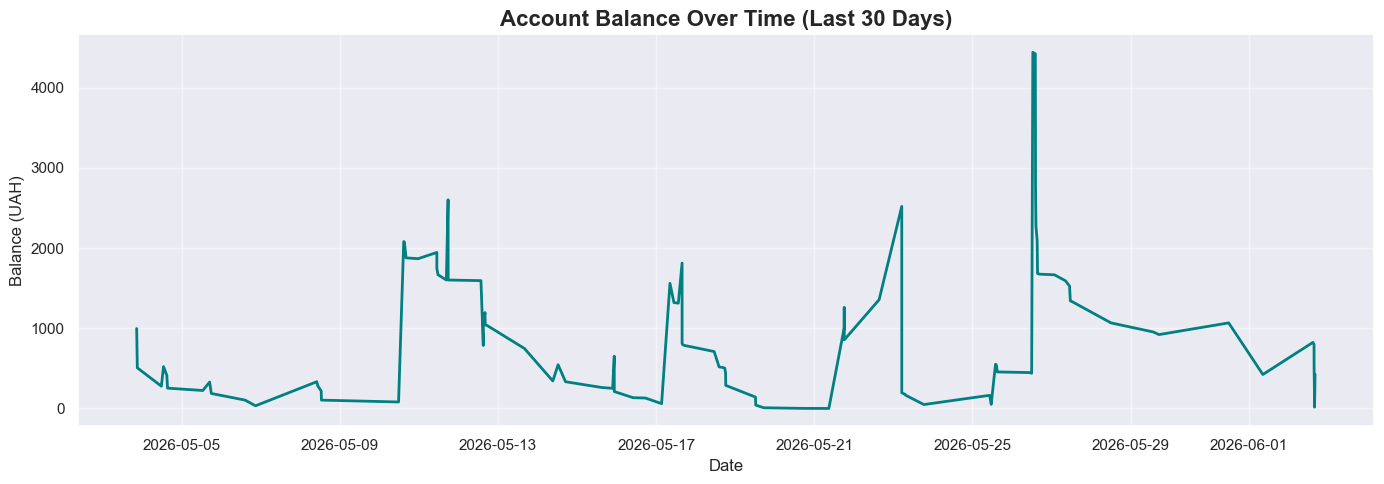

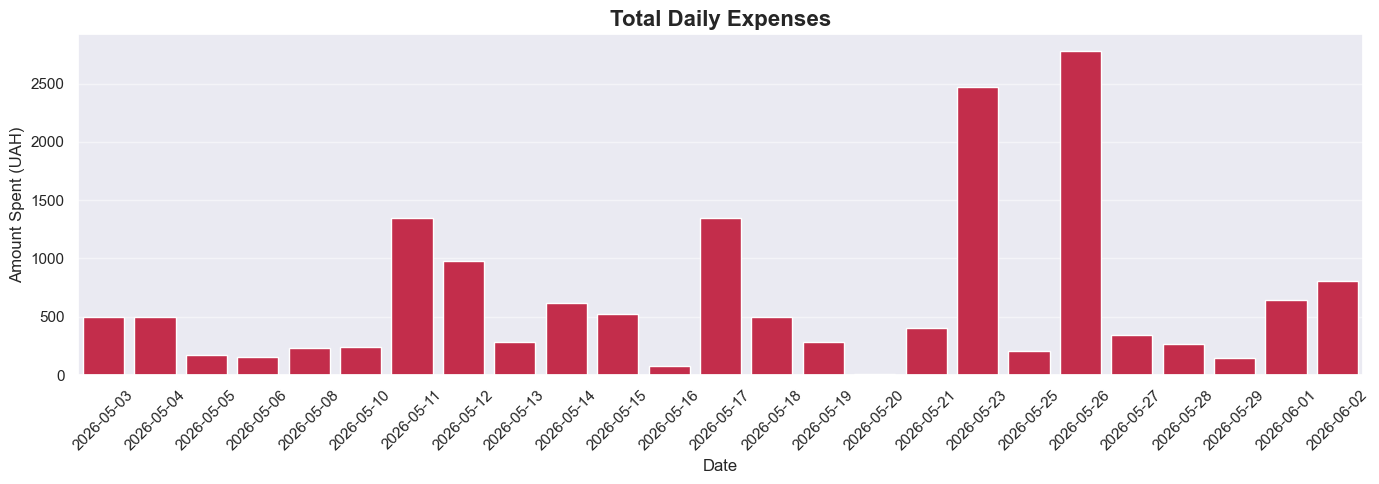

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="deep")

plt.figure(figsize=(14, 5))
sns.lineplot(data=df, x='time', y='balance', color='teal', linewidth=2)
plt.title("Account Balance Over Time (Last 30 Days)", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Balance (UAH)", fontsize=12)
plt.tight_layout()
plt.show()

expenses = df[df['amount'] < 0].copy()
expenses['expense_amount'] = expenses['amount'].abs()

expenses['date'] = expenses['time'].dt.date
daily_expenses = expenses.groupby('date')['expense_amount'].sum().reset_index()

plt.figure(figsize=(14, 5))
ax = sns.barplot(data=daily_expenses, x='date', y='expense_amount', color='crimson')
plt.title("Total Daily Expenses", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Amount Spent (UAH)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Category Analysis (MCC Mapping)
Translating Merchant Category Codes into human-readable labels to analyze the distribution of expenses across different spending categories.

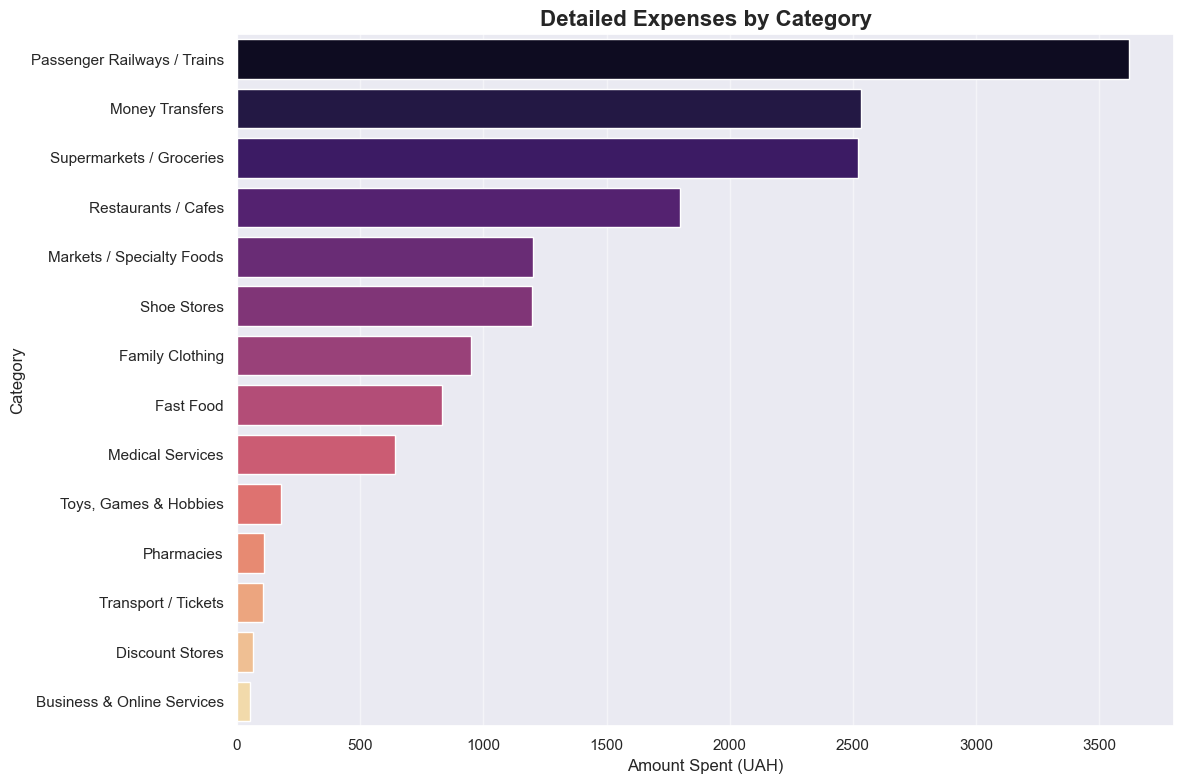


Full Spending Breakdown:


,category,expense_amount
0,Passenger Railways / Trains,3622.82
1,Money Transfers,2534.35
2,Supermarkets / Groceries,2519.09
3,Restaurants / Cafes,1800.00
4,Markets / Specialty Foods,1201.87
5,Shoe Stores,1198.00
6,Family Clothing,948.00
7,Fast Food,833.00
8,Medical Services,643.20
9,"Toys, Games & Hobbies",179.50


In [14]:
# Expanded MCC mapping dictionary
mcc_dict = {
    5912: 'Pharmacies',
    5122: 'Drugs & Pharmacies',
    5812: 'Restaurants / Cafes',
    5814: 'Fast Food',
    5411: 'Supermarkets / Groceries',
    5462: 'Bakeries',
    5499: 'Markets / Specialty Foods',
    5441: 'Candy / Confectionery',
    5811: 'Caterers',
    7832: 'Cinemas',
    7941: 'Sports / Recreation',
    5641: 'Children\'s Apparel',
    5651: 'Family Clothing',
    5691: 'Apparel Stores',
    5661: 'Shoe Stores',
    5697: 'Tailoring / Alterations',
    5977: 'Cosmetics',
    5211: 'Building Materials',
    5942: 'Bookstores',
    5995: 'Pet Stores',
    5541: 'Gas Stations',
    8099: 'Medical Services',
    5311: 'Department Stores',
    5200: 'Home Goods',
    5399: 'Miscellaneous Goods',
    4812: 'Telecom Equipment / Phones',
    5300: 'Wholesale',
    5310: 'Discount Stores',
    5722: 'Household Appliances',
    4111: 'Transport / Tickets',
    4829: 'Money Transfers',
    4814: 'Telecommunication Services',
    4112: 'Passenger Railways / Trains',
    5945: 'Toys, Games & Hobbies',
    7399: 'Business & Online Services'
}

expenses['category'] = expenses['mcc'].apply(lambda x: mcc_dict.get(x, f'Other (Code: {x})'))

category_totals = expenses.groupby('category')['expense_amount'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(
    data=category_totals,
    x='expense_amount',
    y='category',
    hue='category',
    palette='magma',
    legend=False
)
plt.title("Detailed Expenses by Category", fontsize=16, fontweight='bold')
plt.xlabel("Amount Spent (UAH)", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.tight_layout()
plt.show()

print("\nFull Spending Breakdown:")
display(category_totals)

## 6. Temporal Analysis & Feature Engineering
Extracting day of the week from the transaction timestamps to identify weekly spending patterns and prepare features for future machine learning models.

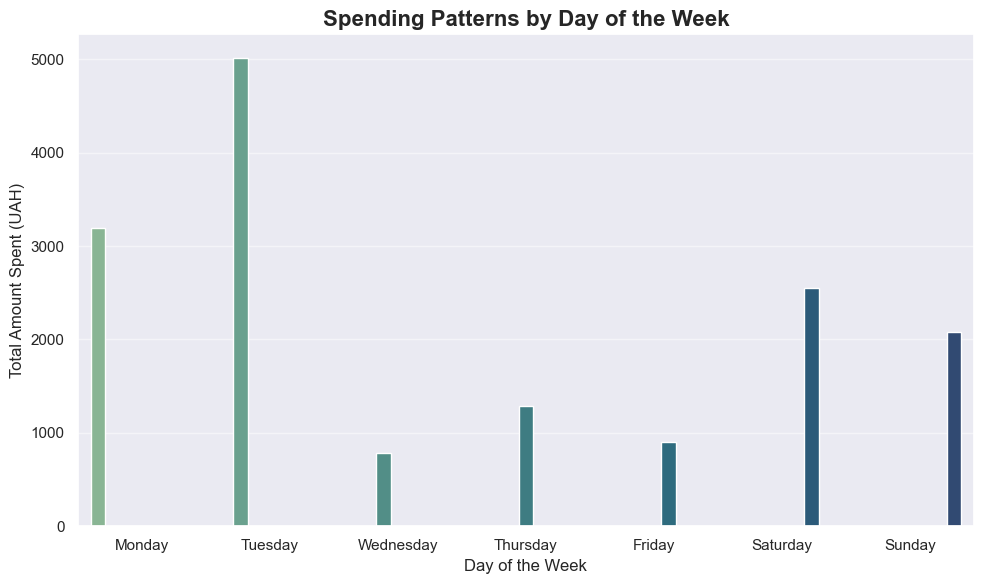

In [15]:
expenses['day_of_week'] = expenses['time'].dt.day_name()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
expenses['day_of_week'] = pd.Categorical(expenses['day_of_week'], categories=days_order, ordered=True)

weekly_patterns = expenses.groupby('day_of_week', observed=False)['expense_amount'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=weekly_patterns,
    x='day_of_week',
    y='expense_amount',
    hue='day_of_week',
    palette='crest',
    legend=False
)
plt.title("Spending Patterns by Day of the Week", fontsize=16, fontweight='bold')
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Total Amount Spent (UAH)", fontsize=12)
plt.tight_layout()
plt.show()